In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

This is an EDA about Renewable Energy in California. We are diving into questions that suggest at what optimal conditions does renewable energy rise such as with humidity, temperature, Wind Speed, etc.

The Questions we are going to be focusing on today are 5 Main Questions:

1. Wind Speed
2. Humidity
3. Temperature
4. Solar Radiation (DHI, DNI, and GHI) across Multiple Seasons
5. What seasons are meant for solar or wind.

In [7]:
# Processing and loading (Plus functions)

dataset = pd.read_csv("Database.csv")
print(dataset.head())
print(dataset.info())

def process_data(data):
    data.columns = data.columns.str.strip()
    data = data.dropna().drop_duplicates()
    data['Time'] = data['Time'].astype(str).str.strip()
    data['Time'] = pd.to_datetime(data['Time'], format='%Y-%m-%d-T%H:%M')
    return data

def average(data):
    df = data.set_index('Time').sort_index()
    
    num_cols = df.select_dtypes(include=['number']).columns
    
    daily = df[num_cols].resample('D').mean()
    monthly = daily.rolling(window=30, min_periods=1, center=True).mean()
    
    date_floor = data['Time'].dt.floor('D')
    
    for col in num_cols:
        data[f'{col}_monthly'] = date_floor.map(monthly[col])
        
    return data

def graph_data(data, dependent_var, units, ax=None):
    x_axis = data['Time']
    y_axis = data[f"{dependent_var}_monthly"]
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
        standalone = True
    else:
        standalone = False
        
    ax.plot(x_axis, y_axis, color='blue', linewidth=1)
    ax.set_title(f'{dependent_var.replace('_', ' ').title()} Over Time')
    ax.set_ylabel(f"{dependent_var.replace('_', ' ').title()} ({units})")
    ax.grid(True, linestyle='--', alpha=0.3)
    
    if standalone:
        ax.set_xlabel('Time')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

processed_data = average(process_data(dataset))
print(processed_data.head())
print(processed_data.info())


           Time               Season  Day_of_the_week  DHI    DNI    GHI     \
0      0   2019-01-01-T00:00       1                1    0.0    0.0     0.0   
1      1   2019-01-01-T00:05       1                1    0.0    0.0     0.0   
2      2   2019-01-01-T00:10       1                1    0.0    0.0     0.0   
3      3   2019-01-01-T00:15       1                1    0.0    0.0     0.0   
4      4   2019-01-01-T00:20       1                1    0.0    0.0     0.0   

   Wind_speed          Humidity            Temperature            \
0                2.88              56.036                   1.82   
1                2.88              56.036                   1.82   
2                2.88              56.194                   1.78   
3                2.88              56.344                   1.74   
4                2.84              56.440                   1.72   

   PV_production  Wind_production  Electric_demand  
0              0             2810            22216  
1         

Here is a Confusion Matrix diving into the connections between these weather conditions.

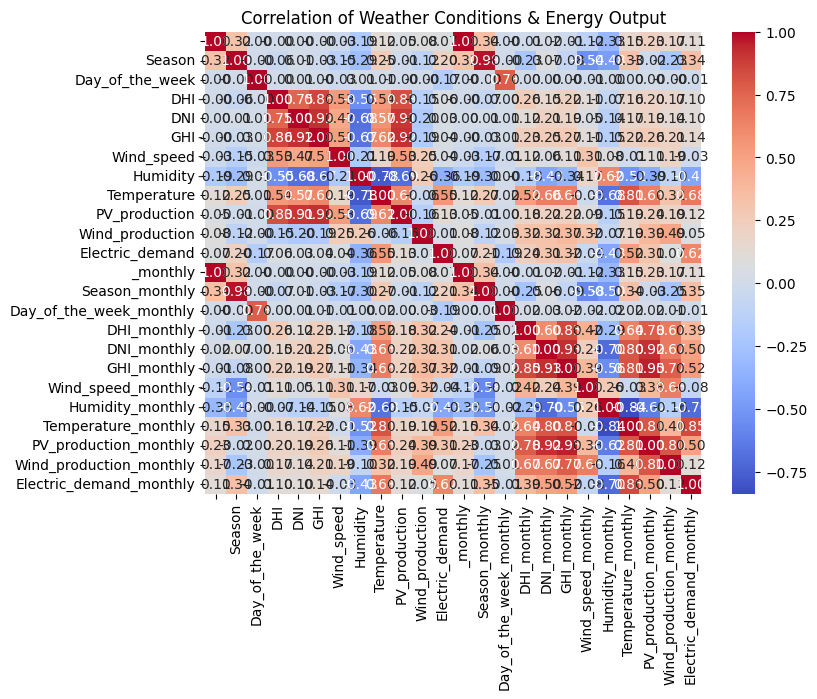

In [8]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
# Exclude the 'Time' column for correlation
sns.heatmap(processed_data.drop(columns=['Time']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation of Weather Conditions & Energy Output")
plt.show()

**Question 1: How does Wind Speed affect Wind Power Usage?**

Text(0.5, 0, 'Time')

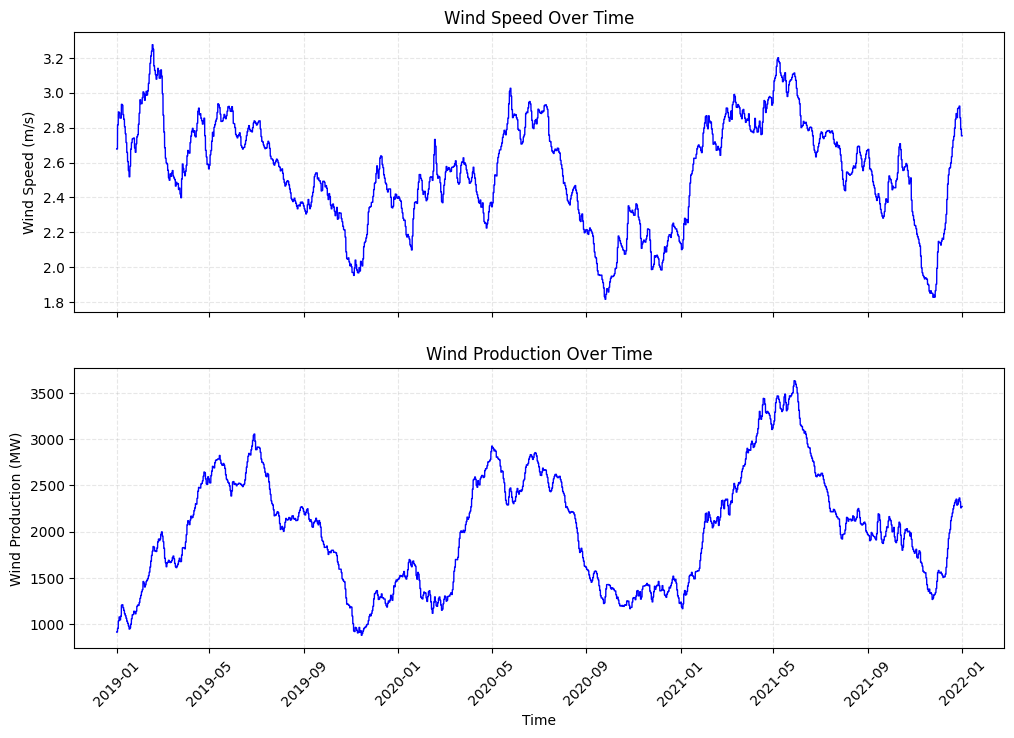

In [9]:
# Graphing

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8))

# Wind Speed Graph
graph_data(processed_data, 'Wind_speed', 'm/s', ax=ax1)

# Wind Power Over Time Graph
graph_data(processed_data, 'Wind_production', 'MW', ax=ax2)

plt.xticks(rotation=45)
ax2.set_xlabel('Time')

As we can see from this graph, wind power wasn't correlated with wind speed until Sepetember 2019, when since then, it has correlated with Wind Speed to some extent.

**Question 2: How does Humidity affect both Solar and Wind power?**

Text(0.5, 0, 'Time')

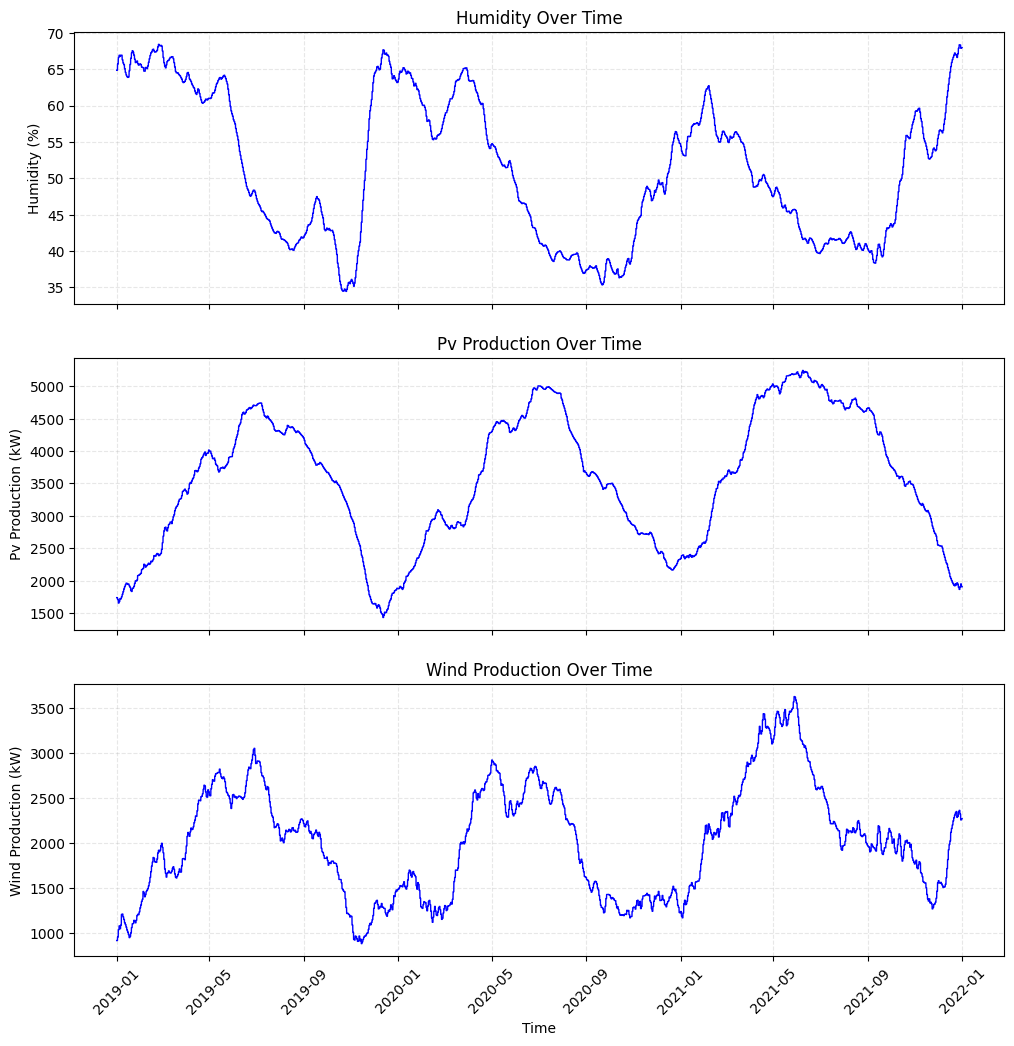

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(12, 12))

# Wind Speed Graph
graph_data(processed_data, 'Humidity', '%', ax=ax1)

# Solar Power Graph
graph_data(processed_data, 'PV_production', 'kW', ax=ax2)

# Wind Power Graph
graph_data(processed_data, 'Wind_production', 'kW', ax=ax3)

plt.xticks(rotation=45)
ax3.set_xlabel('Time')

At times when there is a high amount of Humidity, both renewable energy outputs are lower. In contrast, times with low humidity have higher renewable power output, showing an inverse relationship between renewable energy production and humidity.

**Question 3 How much of an impact does Temperature have on Renewables?**

Text(0.5, 0, 'Time')

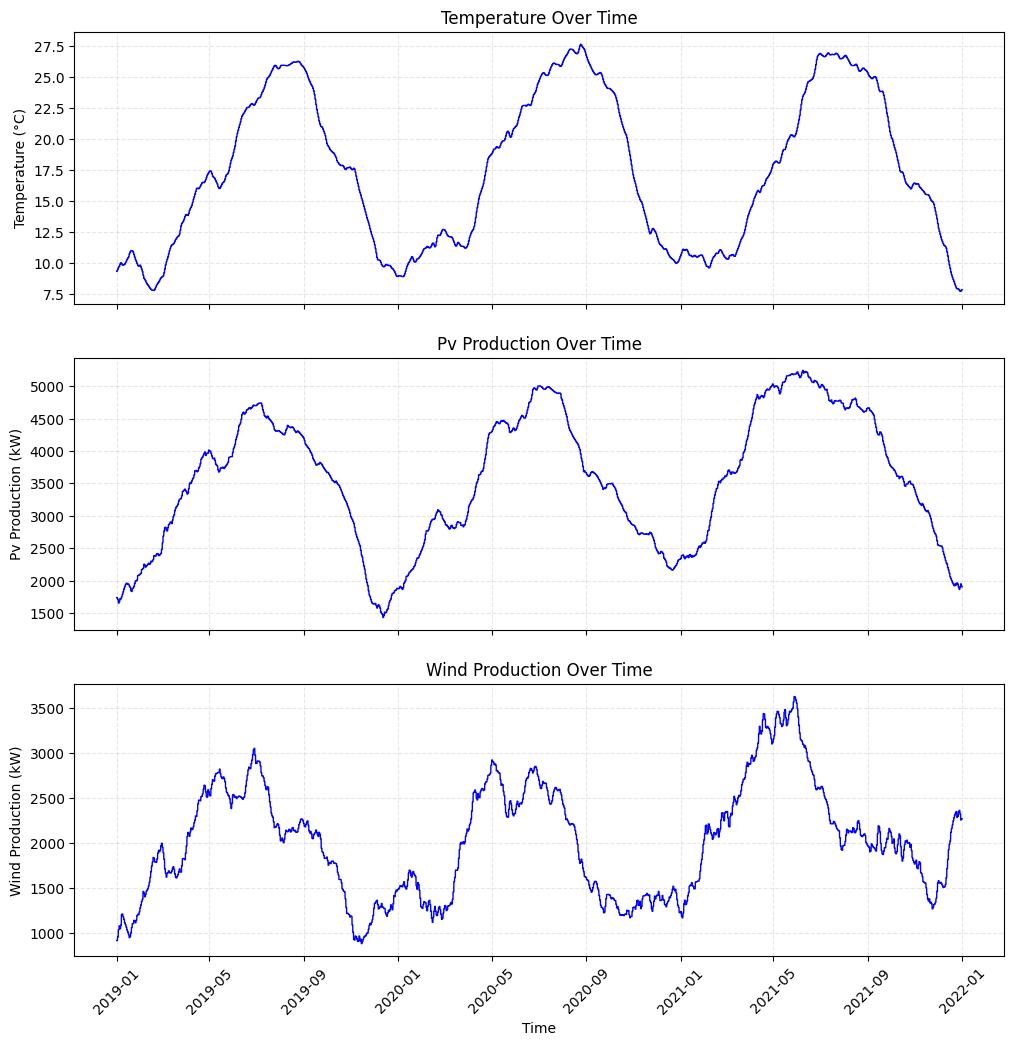

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(12, 12))

# Temperature Graph
graph_data(processed_data, 'Temperature', '°C', ax=ax1)

# Solar Power Graph
graph_data(processed_data, 'PV_production', 'kW', ax=ax2)

# Wind Power Graph
graph_data(processed_data, 'Wind_production', 'kW', ax=ax3)

plt.xticks(rotation=45)
ax3.set_xlabel('Time')

There is a positive relationship between renewable energy usage and temperature, suggesting that as temperatures goes up, renewable energy production goes up.

**Question 4. How does Photovoltaic Radiation change throughout Multiple Seasons?**

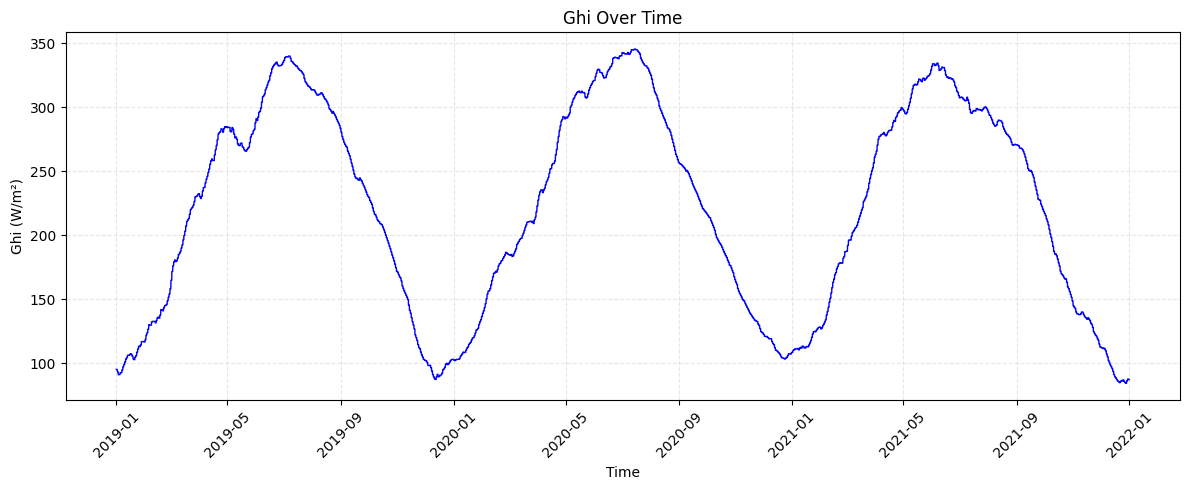

In [12]:
# GHI Graph
graph_data(processed_data, 'GHI', 'W/m²')

We see that PV Radiation is at a low point around the winter months and a high point around the summer months.

**Question 5. What Seasons Correlate with Solar and Wind Production?**

Text(0.5, 0, 'Time')

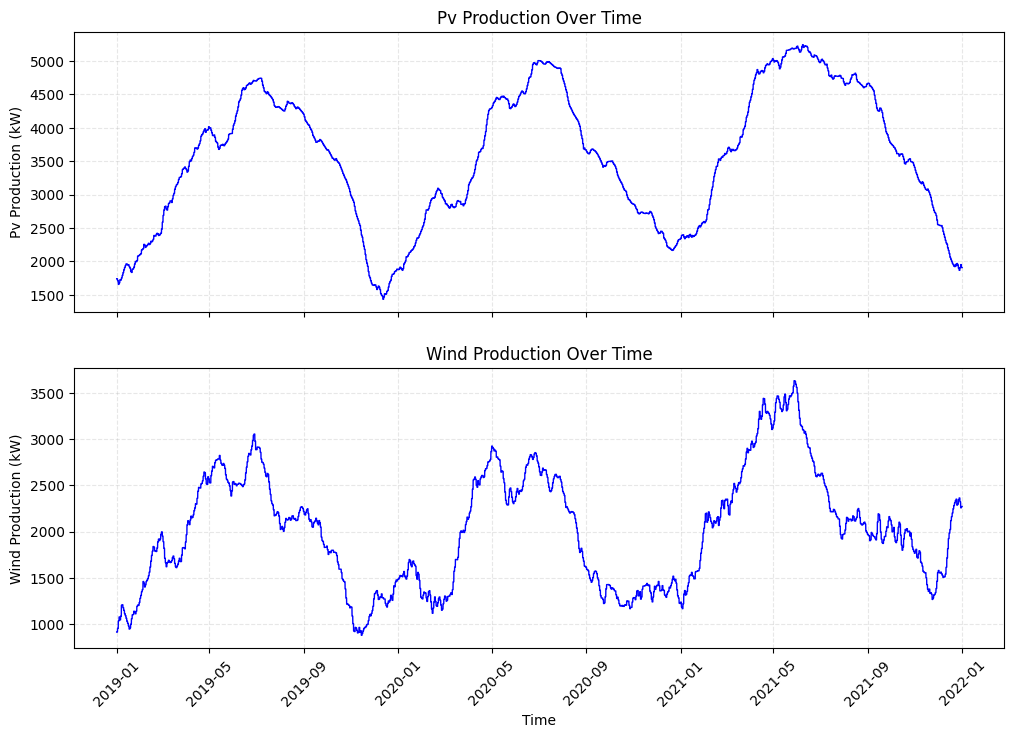

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8))
# Solar Power Graph
graph_data(processed_data, 'PV_production', 'kW', ax=ax1)

# Wind Power Graph
graph_data(processed_data, 'Wind_production', 'kW', ax=ax2)

plt.xticks(rotation=45)
ax2.set_xlabel('Time')

The graph shows that Renewables in general are more powerful in the summer months and weaker in the winter months, showing that other alternatives such as gas and nuclear are needed for the winter months.

**Conclusions**

This EDA shows that while renewables sources is more ideal in a zero carbon world, some form of carbon emitting energy sources, if not nuclear energy, has to be added as renewable projects face physical challenges with battery storage. This is especially relevant in the winter months because renewable sources don't generate enough electricity to offset the electricity demand, further proving the argument that a mixed energy system has to be developed to ensure grid stability and predictable energy for households.